# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [29]:
# filter dplyr warnings
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(raw_data.shape[0])

7214


In [31]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [32]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# type conversions
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# derived factors
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

race_order = ["Caucasian"] + [x for x in df["race"].dropna().unique() if x != "Caucasian"]
df["race_factor"] = pd.Categorical(df["race"], categories=race_order)

df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])

df["score_factor"] = pd.Categorical(
    ["HighScore" if x != "Low" else "LowScore" for x in df["score_text"]],
    categories=["LowScore", "HighScore"]
)

print(df.shape[0])

6172


In [33]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [34]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


Higher COMPAS scores are slightly correlated with a longer length of stay.

In [35]:
df["length_of_stay"] = (
    df["c_jail_out"].dt.date - df["c_jail_in"].dt.date
).apply(lambda x: x.days)

print(df["length_of_stay"].corr(df["decile_score"]))

0.2073296916147045


After filtering we have the following demographic breakdown:

In [36]:
print(df["age_cat"].value_counts(dropna=False))

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [37]:
print(df["race"].value_counts(dropna=False))

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [38]:
race_counts = df["race"].value_counts()

print("Black defendants: %.2f%%" % (race_counts["African-American"] / len(df) * 100))
print("White defendants: %.2f%%" % (race_counts["Caucasian"] / len(df) * 100))
print("Hispanic defendants: %.2f%%" % (race_counts["Hispanic"] / len(df) * 100))
print("Asian defendants: %.2f%%" % (race_counts["Asian"] / len(df) * 100))
print("Native American defendants: %.2f%%" % (race_counts["Native American"] / len(df) * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [39]:
print(df["score_text"].value_counts(dropna=False))

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [40]:
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [41]:
print(df["sex"].value_counts(dropna=False))

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [42]:
sex_counts = df["sex"].value_counts()

print("Men: %.2f%%" % (sex_counts["Male"] / len(df) * 100))
print("Women: %.2f%%" % (sex_counts["Female"] / len(df) * 100))

Men: 80.96%
Women: 19.04%


In [43]:
print(df[df["two_year_recid"] == 1].shape[0])

2809


In [44]:
recid_percent = df[df["two_year_recid"] == 1].shape[0] / len(df) * 100
print("Two-year recidivism rate: %.2f%%" % recid_percent)

Two-year recidivism rate: 45.51%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

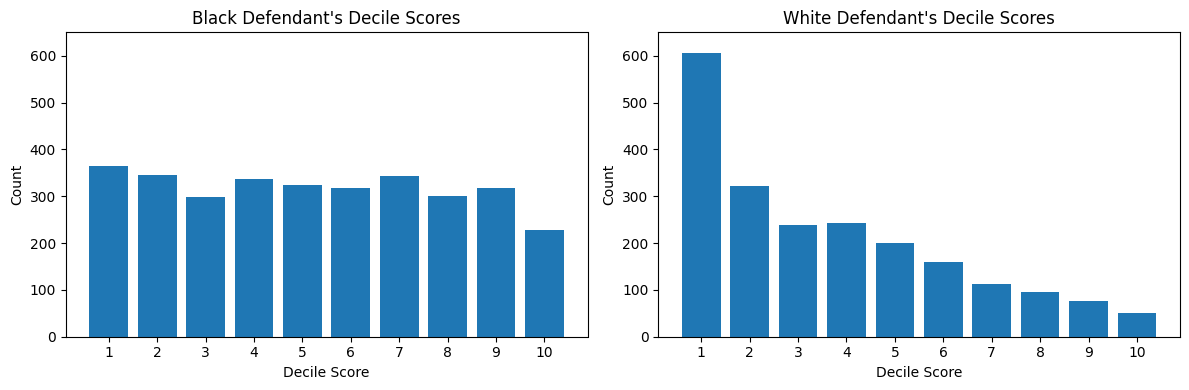

In [45]:
import matplotlib.pyplot as plt

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

black_counts = black_df["decile_score"].value_counts().sort_index()
white_counts = white_df["decile_score"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(black_counts.index.astype(str), black_counts.values)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

axes[1].bar(white_counts.index.astype(str), white_counts.values)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [46]:
print(pd.crosstab(df["decile_score"], df["race"]))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [47]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

df["score_binary"] = df["score_factor"].map({"LowScore": 0, "HighScore": 1}).astype(int)

model_glm = smf.glm(
    "score_binary ~ C(gender_factor, Treatment(reference='Male')) + C(age_factor, Treatment(reference='25 - 45')) + C(race_factor, Treatment(reference='Caucasian')) + priors_count + C(crime_factor, Treatment(reference='F')) + two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Sun, 29 Mar 2026   Deviance:                       6168.4
Time:                        22:13:42   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [48]:
import math

control = math.exp(-1.52554) / (1 + math.exp(-1.52554))
result = math.exp(0.47721) / (1 - control + (control * math.exp(0.47721)))

print(control)
print(result)

0.17864717443340628
1.4528408658138932


Women are 19.4% more likely than men to get a higher score.

In [49]:
result = math.exp(0.22127) / (1 - control + (control * math.exp(0.22127)))
print(result)

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [50]:
result = math.exp(1.30839) / (1 - control + (control * math.exp(1.30839)))
print(result)

2.4961202077189455


In [51]:
df["pred_prob"] = model_glm.predict(df)

df["pred_class"] = pd.Categorical(
    ["Recid" if x >= 0.5 else "No Recid" for x in df["pred_prob"]],
    categories=["No Recid", "Recid"]
)

In [52]:
from sklearn.metrics import confusion_matrix

print("\n── Overall Confusion Matrix \n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.to_numpy().sum()

print("\nAccuracy  : %.3f" % ((TP + TN) / n))
print("Precision : %.3f" % (TP / (TP + FP)))
print("Recall    : %.3f" % (TP / (TP + FN)))
print("FPR       : %.3f" % (FP / (FP + TN)))
print("FNR       : %.3f" % (FN / (FN + TP)))


── Overall Confusion Matrix 

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [53]:
print("\n\n── Confusion Matrix by Race \n")

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = (
    df.groupby("race")
    .apply(lambda x: pd.Series({
        "n": len(x),
        "TP": ((x["pred"] == 1) & (x["actual"] == 1)).sum(),
        "TN": ((x["pred"] == 0) & (x["actual"] == 0)).sum(),
        "FP": ((x["pred"] == 1) & (x["actual"] == 0)).sum(),
        "FN": ((x["pred"] == 0) & (x["actual"] == 1)).sum()
    }))
    .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race 

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [54]:
print("\n\n── FPR and FNR Disparity by Race \n")

white_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
white_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race 

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536
